In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np

In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))
# GFS  Global Forecast System
env.set_atmospheric_model(type="Forecast", file="GFS")


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  78.927 km (ASL): 9.5484 m/s²


Launch Site Details

Launch Date: 2026-07-22 12:00:00 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.82 W    7568202.63 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 475.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 78.927 km
Forecast Time Period: from 2026-07-14 00:00:00 to 2026-08-06 12:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 4.69 m/s
Surface Wind Direction: 18.70°
Surface Wind Heading: 198.70°
Surface Pressure: 96034.04 hPa
Surface Temperature: 294.18 K
Surface Air Density: 113.719 kg/m³
Surface Speed of Sound: 343.84 m/s


Earth Model Details

Earth Radius at Launc

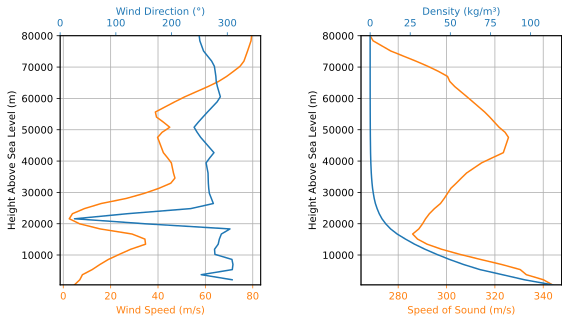

In [4]:
env.info()

In [5]:
# motor

motor_data = pd.read_csv("motor.csv")

In [23]:
print("DataFrame columns:", motor_data.columns)
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])


# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 1.86,
    dry_inertia=(0.04718349, 0.04718349, 0.00178498),
    nozzle_radius=0.020715,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=0.0315,
    grain_initial_inner_radius=0.010,
    grain_initial_height=0.116,
    grain_separation=0,
    grains_center_of_mass_position=0.174, 
    center_of_dry_mass_position=0.24, # verificar
    nozzle_position=-0.05, 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.008,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("\nSolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')

SolidMotor initialized successfully!


Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.008 m

Grain Details
Number of Grains: 3
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.01 m
Grain Height: 0.116 m
Grain Volume: 0.000 m3
Grain Mass: 0.569 kg

Motor Details
Total Burning Time: 2.82 s
Total Propellant Mass: 1.707 kg
Structural Mass Ratio: 0.521
Average Propellant Exhaust Velocity: 1112.480 m/s
Average Thrust: 673.437 N
Maximum Thrust: 926.4431 N at 2.79 s after ignition.
Total Impulse: 1899.091 Ns



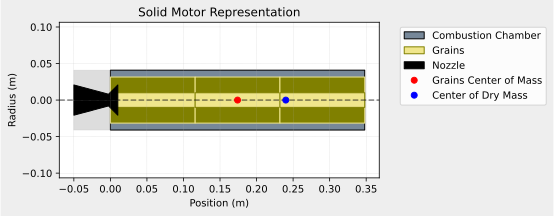

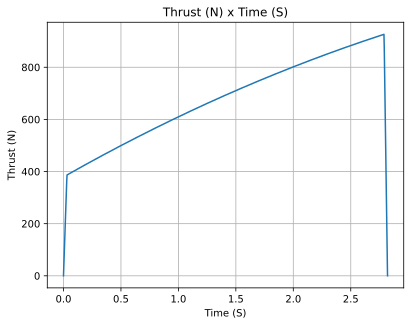

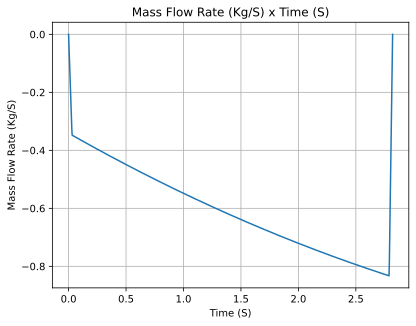

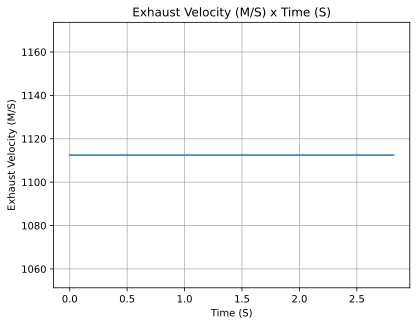

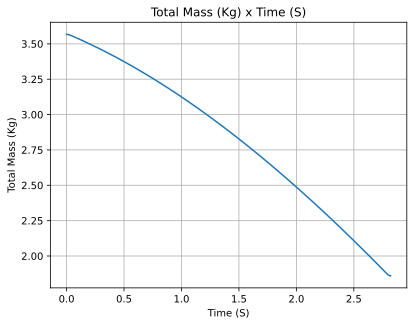

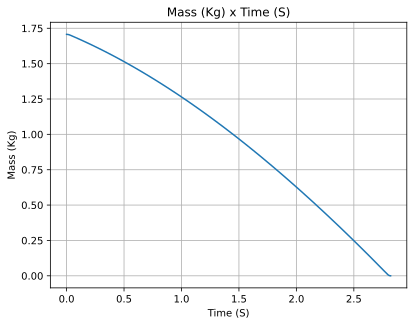

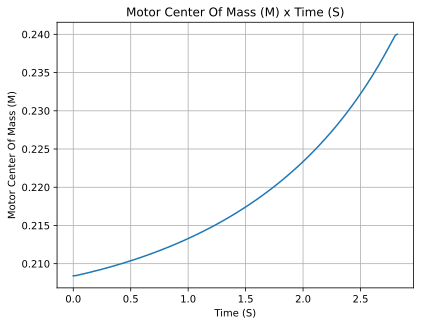

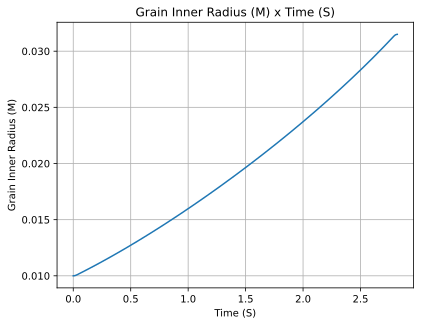

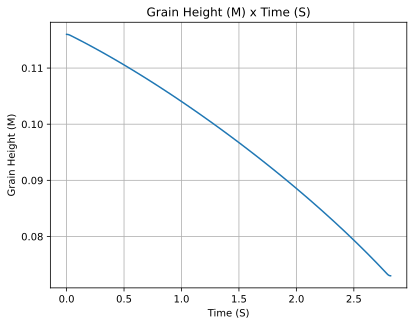

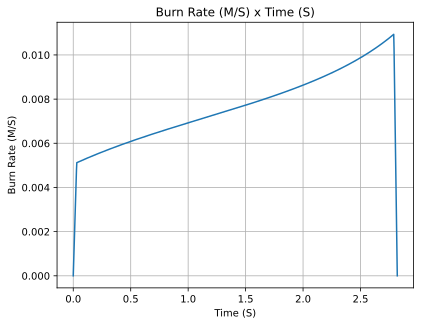

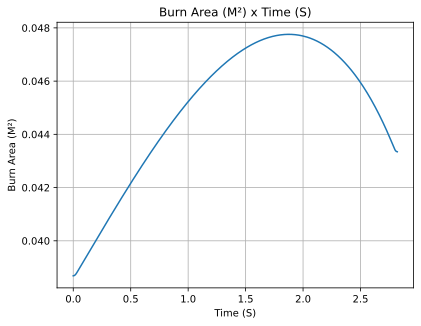

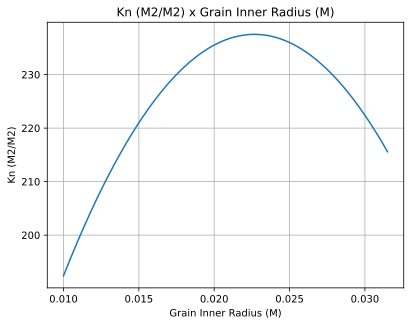

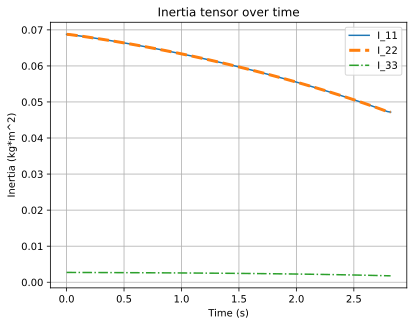

In [24]:
Dedalo_motor.all_info()

In [33]:
# Function to read and process drag curve CSVs
def load_drag_curve(filepath):
    # Ler com separador ';' e decimal '.' (os arquivos usam ponto como separador decimal)
    drag_data = pd.read_csv(filepath, delimiter=',', skipinitialspace=True, header=None, decimal='.')

    # Remover colunas totalmente vazias (por exemplo linhas terminando com ';;')
    drag_data.dropna(axis=1, how='all', inplace=True)

    # Garantir pelo menos duas colunas
    if drag_data.shape[1] < 2:
        raise ValueError(f"Drag curve file {filepath} does not contain enough columns (expected at least 2).")

    # Usar apenas as duas primeiras colunas (Mach, Cd)
    drag_data = drag_data.iloc[:, :2]

    # Converter para numérico, coerindo erros para NaN
    drag_data = drag_data.apply(pd.to_numeric, errors='coerce')

    # Remover linhas com NaN resultantes da conversão
    drag_data.dropna(inplace=True)

    # Converter para array NumPy
    drag_array = drag_data.values

    # Remover linhas duplicadas
    drag_array = np.unique(drag_array, axis=0)

    # Ordenar por Mach (primeira coluna)
    drag_array = drag_array[drag_array[:, 0].argsort()]

    # Pequeno jitter para evitar colinearidade exata (só se tiver mais de 1 ponto)
    if drag_array.shape[0] > 1:
        jitter_amount = 1e-9 * (drag_array.max(axis=0) - drag_array.min(axis=0))
        # proteger contra jitter 0
        j0 = jitter_amount[0] if jitter_amount[0] != 0 else 1e-12
        j1 = jitter_amount[1] if jitter_amount[1] != 0 else 1e-12
        drag_array[:, 0] = drag_array[:, 0] + np.random.randn(drag_array.shape[0]) * j0
        drag_array[:, 1] = drag_array[:, 1] + np.random.randn(drag_array.shape[0]) * j1

    return drag_array

# Load and process drag curve data
power_off_drag_array = load_drag_curve("drag_of.csv")
power_on_drag_array = load_drag_curve("drag_on.csv")

print('power_off_drag_array shape:', power_off_drag_array.shape)
print('power_on_drag_array shape:', power_on_drag_array.shape)

# Salvar arrays processados em CSVs temporários para compatibilidade com Rocket
import os
power_off_path = "poweroff_processed.csv"
power_on_path = "poweron_processed.csv"

pd.DataFrame(power_off_drag_array).to_csv(power_off_path, index=False, header=False)
pd.DataFrame(power_on_drag_array).to_csv(power_on_path, index=False, header=False)

Dedalo_rocket = Rocket(
    radius = 0.038,
    mass=8.119,
    inertia=(2281370.34*(10**-9), 474090509.51*(10**-9), 474109826.94*(10**-9)),
    power_off_drag=power_off_path,
    power_on_drag=power_on_path,
    center_of_mass_without_motor=0.141,
    coordinate_system_orientation="nose_to_tail",
)

print("Rocket object created successfully!")


power_off_drag_array shape: (717, 2)
power_on_drag_array shape: (78, 2)
Rocket object created successfully!


In [34]:
Dedalo_rocket.add_motor(Dedalo_motor, position=1.5)

In [35]:
nose_cone = SRrocket.add_nose(
    length=0.197, kind="Ogive", position=0
)

aletas = SRrocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.10,
    tip_chord=0.047,
    span=0.057,
    position=1.395,
    cant_angle=58.99,
)


In [36]:
main = SRrocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=750,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)

In [37]:
rail_buttons = SRrocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

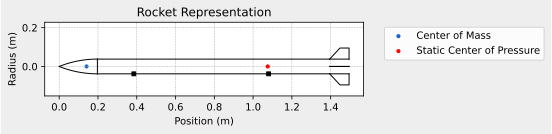

In [38]:
SRrocket.draw()